# Bayesian inversion of diffusivity in Poisson equation (FEniCSx)

Run in **`neuralopv2`**. True forward model by default; set `load_surrogate=True` for neural operators.

**Prerequisite:** Regenerate `Results/ground_truth/data.npz` via `Generate_GroundTruth.ipynb` on the FEniCSx mesh.

MCMC is expensive (10k samples). Use `run_mcmc=False` for setup checks; set `n_samples` small for smoke tests.



In [ ]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import pickle
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from dolfinx import mesh
from dolfinx.fem import functionspace
from dolfinx.mesh import CellType
from mpi4py import MPI
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.interpolate import griddata

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parents[2]
POISSON_DIR = ROOT / "survey_work/problems/poisson"

sys.path.insert(0, str(ROOT / "src/plotting"))
sys.path.insert(0, str(ROOT / "src/data"))
sys.path.insert(0, str(ROOT / "src/prior"))
sys.path.insert(0, str(ROOT / "src/mcmc"))
sys.path.insert(0, str(ROOT / "src/nn/deeponet"))
sys.path.insert(0, str(ROOT / "src/nn/pcanet"))
sys.path.insert(0, str(ROOT / "src/nn/fno"))
sys.path.insert(0, str(ROOT / "src/nn/mlp"))
sys.path.insert(0, str(POISSON_DIR))

from compute_sample_errors import compute_sample_errors
from field_plot import field_plot
from load_data_and_deeponet import load_data_and_deeponet
from load_data_and_fno import load_data_and_fno
from load_data_and_pcanet import load_data_and_pcanet
from mcmc import MCMC
from mcmc_plot_fields import mcmc_plot_fields, mcmc_plot_fields_base
from plot_curve import plot_curve
from plot_mix_collection import plot_collection
from point_plot import point_plot
from poissonModel import PoissonModel
from priorSampler import PriorSampler
from surrogateModel import SurrogateModel, SurrogateModelFNO

plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

seed = 0
np.random.seed(seed)
torch.manual_seed(seed)


Repo root: /Users/prashant/Dropbox/Work/Simulations/neuralnet_works/error_corrector_direction/neural_operators


In [2]:
model_path = POISSON_DIR
results_dir = NOTEBOOK_DIR / "Results"
results_dir.mkdir(exist_ok=True)


# Create PoissonModel

In [3]:
prior_ac = 0.005
prior_cc = 0.2
prior_logn_scale = 1
prior_logn_translate = 0.0
nx, ny = 50, 50
fe_order = 1

domain = mesh.create_unit_square(MPI.COMM_WORLD, nx, ny, cell_type=CellType.triangle)
Vm = functionspace(domain, ("Lagrange", fe_order))
Vu = Vm

prior_sampler = PriorSampler(Vm, prior_ac, prior_cc, seed)
model = PoissonModel(Vm, Vu, prior_sampler, prior_logn_scale, prior_logn_translate, seed)
nodes = model.m_nodes


# Load Neural Operators

In [4]:
surrogate_models = None
load_surrogate = False

In [5]:
if load_surrogate:
    def load_deeponet():
        data_path = str(model_path / "data/Poisson_samples.npz")
        nn_path = str(model_path / "DeepONet/Results/model.pkl")
        data, deeponet = load_data_and_deeponet(data_path, nn_path)
        return deeponet

    deeponet = load_deeponet()


In [6]:
if load_surrogate:
    def load_pcanet():
        data_path = str(model_path / "data/Poisson_samples.npz")
        nn_path = str(model_path / "PCANet/Results/model.pkl")
        data, pcanet = load_data_and_pcanet(data_path, nn_path)
        return pcanet

    pcanet = load_pcanet()


In [7]:
if load_surrogate:
    def load_fno():
        data_path = str(model_path / "data/Poisson_FNO_samples.npz")
        nn_path = str(model_path / "FNO/Results/model.pkl")
        data, fno = load_data_and_fno(data_path, nn_path)
        return fno

    fno = load_fno()


In [8]:
if load_surrogate:
    surrogate_models = {'DeepONet': deeponet, 'PCANet': pcanet, 'FNO': fno}

In [9]:
if load_surrogate:
    t1 = time.time()
    w1 = model.samplePrior(transform_m=False)
    w2 = w1.copy()
    t2 = time.time()
    u1 = model.solveFwd(u=None, m=w1, transform_m=True)
    t3 = time.time()
    u2 = surrogate_models["DeepONet"].solveFwd(u=None, m=w1, transform_m=True)
    t4 = time.time()
    print(
        "Poisson forward solve time: {:.3f} sec".format(t3 - t2),
        "DeepONet forward solve time: {:.3f} sec".format(t4 - t3),
    )


# Get ground truth

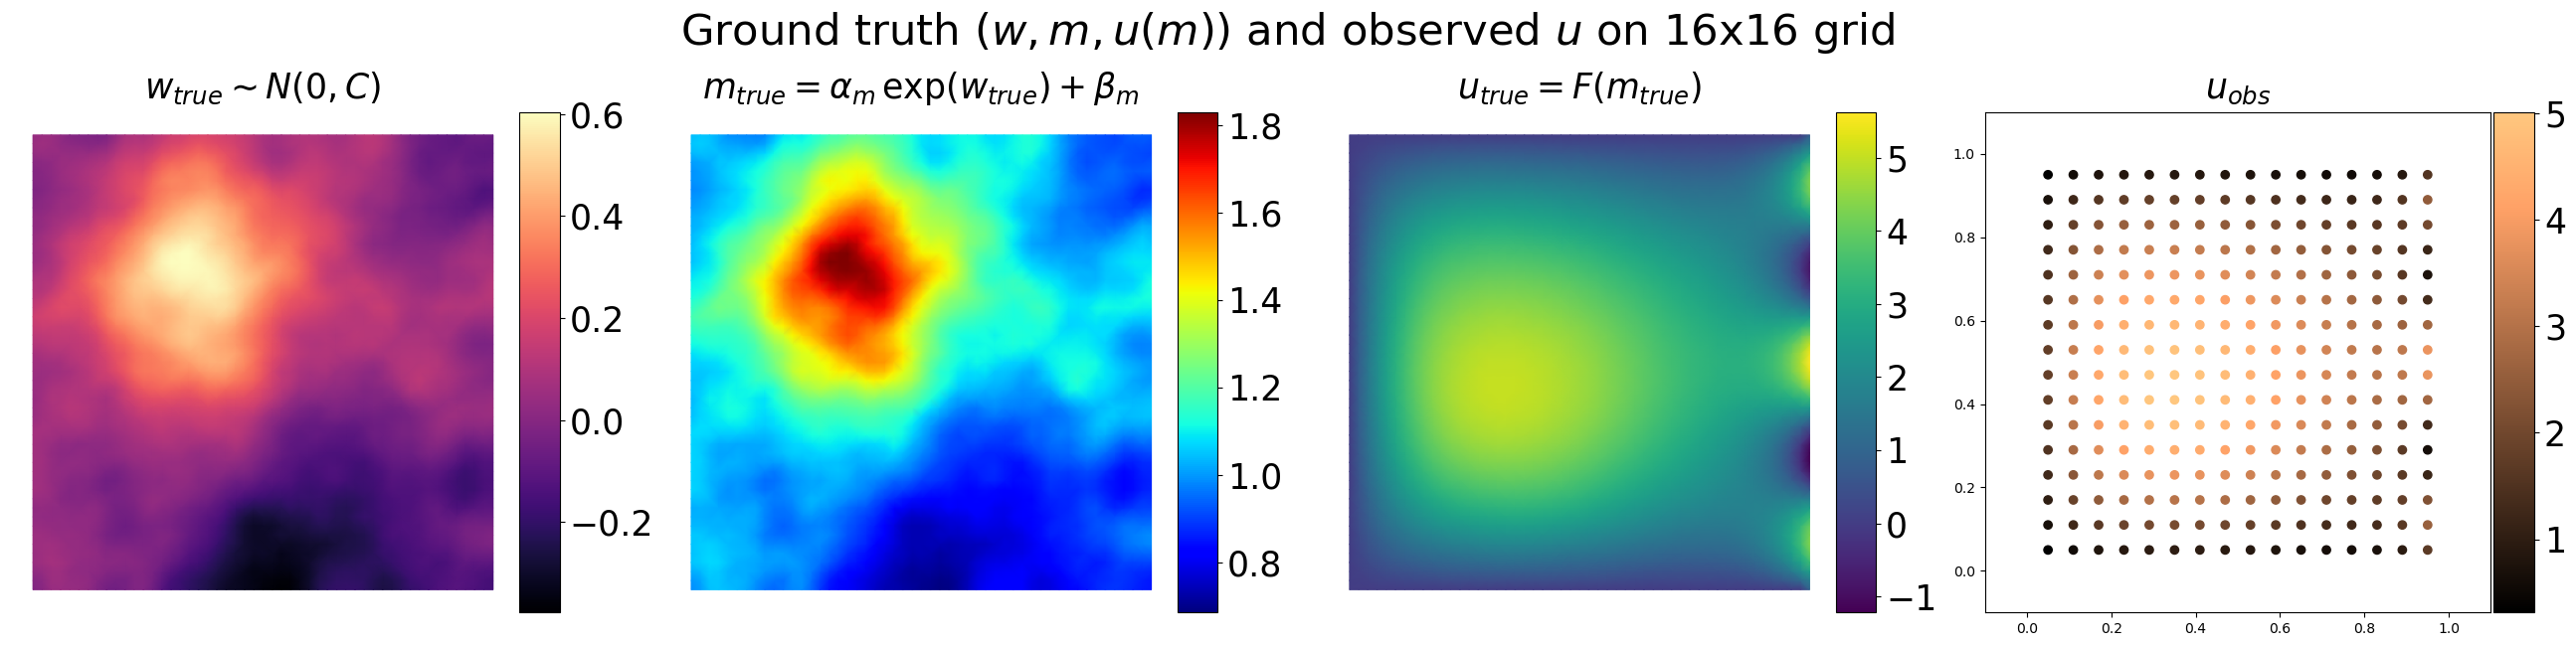

In [10]:
# Load ground truth generated by Generate_GroundTruth.ipynb (regenerate on FEniCSx mesh)
ground_truth_data = np.load(results_dir / "ground_truth/data.npz")
num_grid_x, num_grid_y = ground_truth_data["num_grid_x"], ground_truth_data["num_grid_y"]
w_true = ground_truth_data["w_true"]
m_true = ground_truth_data["m_true"]
u_true = ground_truth_data["u_true"]
x_obs = ground_truth_data["x_obs"]
u_obs = ground_truth_data["u_obs"]

nodes = model.m_nodes

rows, cols = 1, 4
fig, axs = plt.subplots(rows, cols, figsize=(26, 6))
axs = np.atleast_1d(axs).reshape(rows, cols)

uvec = [[w_true, m_true, u_true]]
title_vec = [[
    r"$w_{true} \sim N(0, C)$",
    r"$m_{true} = \alpha_m\, \exp(w_{true}) + \beta_m$",
    r"$u_{true} = F(m_{true})$",
    r"$u_{obs}$",
]]
cmap_vec = [["magma", "jet", "viridis", "copper"]]
sup_title = r"Ground truth $(w, m, u(m))$ and observed $u$ on {}x{} grid".format(
    num_grid_x, num_grid_y
)
fs = 25
y_sup_title = 1.075
savefilename = results_dir / "true_and_obs_w_m_u.png"

for i in range(rows):
    for j in range(cols):
        if j == cols - 1:
            axs[i, j].set_xlim([-0.1, 1.1])
            axs[i, j].set_ylim([-0.1, 1.1])
        if j < cols - 1:
            cbar = field_plot(axs[i, j], uvec[i][j], nodes, cmap=cmap_vec[i][j])
        else:
            cbar = point_plot(axs[i, j], u_obs, x_obs, cmap=cmap_vec[i][j])
        divider = make_axes_locatable(axs[i, j])
        cax = divider.append_axes("right", size="8%", pad=0.03)
        cax.tick_params(labelsize=fs)
        fig.colorbar(cbar, cax=cax, orientation="vertical")
        if j < cols - 1:
            axs[i, j].axis("off")
        if title_vec is not None:
            axs[i, j].set_title(title_vec[i][j], fontsize=fs, pad=10)

fig.tight_layout()
fig.suptitle(sup_title, fontsize=1.25 * fs, y=y_sup_title)
fig.savefig(savefilename, bbox_inches="tight")
plt.show()


## Compute noise

In [11]:
u_obs_mean, u_obs_std = np.mean(u_obs), np.std(u_obs)
sigma_noise = 0.05 * u_obs_mean
print('u_obs_mean = {:.3e}, u_obs_std = {:.3e}, sigma_noise: {:.3e}'.format(u_obs_mean, u_obs_std, sigma_noise))

u_obs_mean = 2.645e+00, u_obs_std = 1.267e+00, sigma_noise: 1.323e-01


# Bayesian parameter estimation setup

In [12]:
surrogate_to_use = None

mcmc = MCMC(model, prior_sampler, ground_truth_data, \
            sigma_noise = sigma_noise, pcn_beta = 0.2, \
            surrogate_to_use = surrogate_to_use, \
            surrogate_models = surrogate_models, \
            seed = seed)

# display low-res files for testing
mcmc.pp_params = {'curve_plot': {'fs': 12, 'lw': 3, 'figsize': (4,3)}, \
                          'field_plot': {'fs': 10, 'y_sup_title': 1.025, 'figsize': (8, 6), 'ttl_pad': 5}}

In [ ]:
n_samples = 10000
n_burnin = 500
pcn_beta = 0.2
print_every = 500
display_plot_every = 5 * print_every

mcmc.surrogate_to_use = None

savepath_base = (
    results_dir
    / f"test_mcmc_results_n_samples_{n_samples:d}_n_burnin_{n_burnin:d}_pcn_beta_{pcn_beta:.3f}_sigma_{sigma_noise:.3e}"
)

if mcmc.surrogate_to_use is not None:
    savepath = savepath_base / f"surrogate_{mcmc.surrogate_to_use}"
else:
    savepath = savepath_base

savepath.mkdir(parents=True, exist_ok=True)
savefilename = "tracer"


MCMC output: /Users/prashant/Dropbox/Work/Simulations/neuralnet_works/error_corrector_direction/neural_operators/survey_work/applications/bayesian_inverse_problem_poisson/Results/test_mcmc_results_n_samples_10000_n_burnin_500_pcn_beta_0.200_sigma_1.323e-01


## True model

--------------------------------------------------
MCMC started with 10000 samples and 500 burnin
PCN beta: 2.000e-01, sigma_noise: 1.323e-01
Model used for solving the forward problem: True Model
Tracer save path: test_mcmc_results_n_samples_10000_n_burnin_500_pcn_beta_0.200_sigma_1.323e-01
Tracer save filename: tracer
--------------------------------------------------
initializing the current state. Initial cost: 2.978e+03
--------------------------------------------------
Burnin:    0, Cost: 2.978e+03
--------------------------------------------------
--------------------------------------------------
Sample:  500, Accepted samples:    0, Acceptance Rate: 0.000e+00, Cost mean: 0.000e+00. 
Tracing 500 samples took 1.172e+02s
Error (%) in w: ||w - w_mean|| = 1.000e+02, ||w - w_sample|| = 1.000e+02
Error (%) in m: ||m - m_mean|| = 2.201e+01, ||m - m_sample|| = 2.201e+01
Error (%) in u: ||u - u_mean|| = 9.361e+00, ||u - u_sample|| = 9.361e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| =

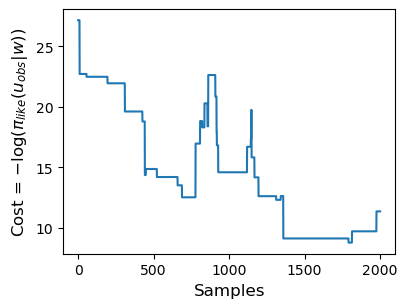

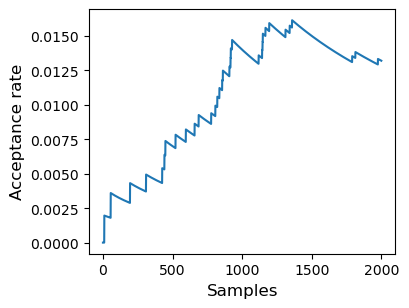

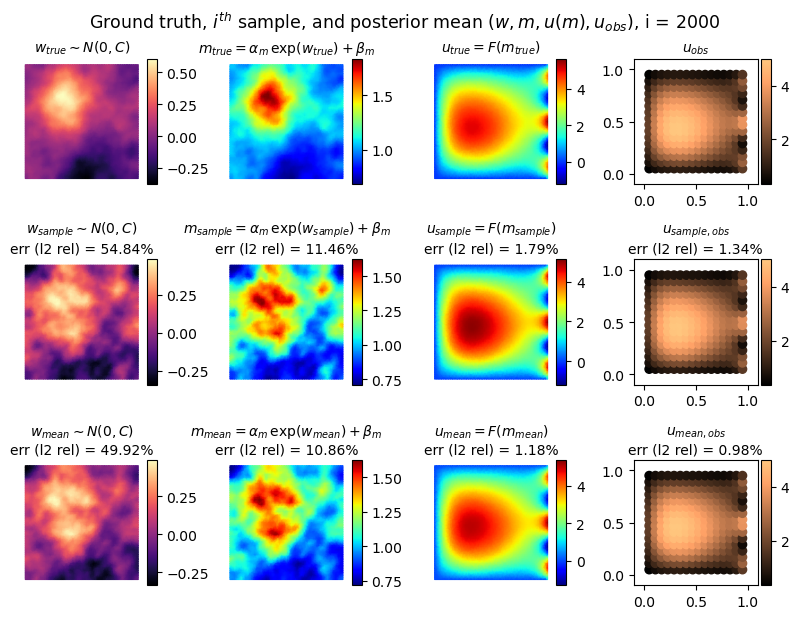

--------------------------------------------------
Sample: 3000, Accepted samples:   38, Acceptance Rate: 1.267e-02, Cost mean: 1.399e+01. 
Tracing 500 samples took 1.320e+02s
Error (%) in w: ||w - w_mean|| = 4.901e+01, ||w - w_sample|| = 5.003e+01
Error (%) in m: ||m - m_mean|| = 1.058e+01, ||m - m_sample|| = 1.023e+01
Error (%) in u: ||u - u_mean|| = 1.197e+00, ||u - u_sample|| = 1.473e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 9.487e-01, ||u_obs - u_obs_sample|| = 1.181e+00
--------------------------------------------------
--------------------------------------------------
Sample: 3500, Accepted samples:   43, Acceptance Rate: 1.229e-02, Cost mean: 1.314e+01. 
Tracing 500 samples took 1.314e+02s
Error (%) in w: ||w - w_mean|| = 4.745e+01, ||w - w_sample|| = 4.796e+01
Error (%) in m: ||m - m_mean|| = 1.011e+01, ||m - m_sample|| = 9.543e+00
Error (%) in u: ||u - u_mean|| = 1.150e+00, ||u - u_sample|| = 1.456e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 9.066e-01, ||u_obs - 

In [ ]:
run_mcmc = True  # set True for full run; use small n_samples for smoke tests

if run_mcmc:
    mcmc.run(
        n_samples=n_samples,
        n_burnin=n_burnin,
        pcn_beta=pcn_beta,
        sigma_noise=sigma_noise,
        print_every=print_every,
        print_lvl=2,
        display_plot_every=display_plot_every,
        savefilename=savefilename,
        init_tracer=True,
        savepath=str(savepath) + "/",
    )


### Load tracer and plot

In [ ]:
tracer_path = savepath / f"{savefilename}.pkl"
load_tracer = pickle.load(open(tracer_path, "rb"))

load_tracer.acceptances, load_tracer.current_acceptance_rate


### DeepONet

In [ ]:
mcmc.surrogate_to_use = "DeepONet"

if mcmc.surrogate_to_use is not None:
    savepath = savepath_base / f"surrogate_{mcmc.surrogate_to_use}"
else:
    savepath = savepath_base

savepath.mkdir(parents=True, exist_ok=True)

run_mcmc = False
if run_mcmc:
    mcmc.run(
        n_samples=n_samples,
        n_burnin=n_burnin,
        pcn_beta=pcn_beta,
        sigma_noise=sigma_noise,
        print_every=print_every,
        print_lvl=2,
        display_plot_every=display_plot_every,
        savefilename=savefilename,
        savepath=str(savepath) + "/",
        init_tracer=True,
    )


### PCANet

In [ ]:
mcmc.surrogate_to_use = "PCANet"

if mcmc.surrogate_to_use is not None:
    savepath = savepath_base / f"surrogate_{mcmc.surrogate_to_use}"
else:
    savepath = savepath_base

savepath.mkdir(parents=True, exist_ok=True)

run_mcmc = False
if run_mcmc:
    mcmc.run(
        n_samples=n_samples,
        n_burnin=n_burnin,
        pcn_beta=pcn_beta,
        sigma_noise=sigma_noise,
        print_every=print_every,
        print_lvl=2,
        display_plot_every=display_plot_every,
        savefilename=savefilename,
        savepath=str(savepath) + "/",
        init_tracer=True,
    )


### FNO

In [ ]:
mcmc.surrogate_to_use = "FNO"

if mcmc.surrogate_to_use is not None:
    savepath = savepath_base / f"surrogate_{mcmc.surrogate_to_use}"
else:
    savepath = savepath_base

savepath.mkdir(parents=True, exist_ok=True)

run_mcmc = False
if run_mcmc:
    mcmc.run(
        n_samples=n_samples,
        n_burnin=n_burnin,
        pcn_beta=pcn_beta,
        sigma_noise=sigma_noise,
        print_every=print_every,
        print_lvl=2,
        display_plot_every=display_plot_every,
        savefilename=savefilename,
        savepath=str(savepath) + "/",
        init_tracer=True,
    )


## Load tracer and plot

In [ ]:
tracer_path = savepath / f"{savefilename}.pkl"
load_tracer = pickle.load(open(tracer_path, "rb"))

load_tracer.acceptances, load_tracer.current_acceptance_rate
